# Q dependence

Fit the saved multitau $g_2$ with a double KWW. Through 350 K there are four reflections and the plot is $\tau_\mathrm{fast}(Q)$ and $\beta_\mathrm{fast}(Q)$. From 360 K on there is only (111); the same fit is used, but the compile is vs temperature.

Do this **one temperature at a time**, inspect the overlays, then save.

What is stored per reflection:
- peak $Q_0=\sqrt{Q_x0^2+Q_y0^2}$ and $dQ$ of every ring
- double-exp parameters for every Q partition
- plotted point = innermost ring (smallest $dQ$)
- error bar = sample standard deviation of $\tau_\mathrm{fast}$ and $\beta_\mathrm{fast}$ across rings

Low → high $Q$: (011), (10-1), (120), (101). Single-peak files: (111).

In [1]:
import sys
sys.path.append('../src/')

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from scan import resolve_work_path
from postprocess import (
    REFLECTION_ORDER,
    SINGLE_PEAK,
    SINGLE_PEAK_SCANS,
    compile_qdep,
    discover_qdep_files,
    discover_results,
    fit_temperature,
    load_temperature_qdep,
    plot_g2_fits,
    plot_qdep,
    plot_tdep,
    print_qdep_table,
    reflection_series,
)

%matplotlib widget

# User parameters

In [50]:
Compound = 'NBH'
Particle = 'A7'
Attenuation = 20

# Four-peak Q-dependence (320–350 K)
#Temperature, Scan = 360, 353
reflections = REFLECTION_ORDER  # ('011', '10-1', '120', '101')

# Single-peak (111) from 360 K on — same cells, just switch to:
Temperature, Scan = 329, 344   # then 380/358, 399/362, 420/363
#reflections = SINGLE_PEAK

# Drop the last N delay points from the fit (same convention as xpcs.ipynb)
trunc = -1

write_back = True   # append g2_fit/ onto each analysis HDF5
save_qdep = True    # write results/qdep_T{T}K.h5

config_path = Path('../configs/config_B10.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}

# Find reflection files

Four peaks through 350 K, or just (111) afterward. The same fit is used either way.

In [51]:
work_path = resolve_work_path(Compound, Scan, Temperature, Attenuation, config=config)
results_dir = work_path / 'results'
files = discover_results(results_dir, reflections=reflections)
print(results_dir)
for label, path in files.items():
    print(f'  ({label})  {path.name}')
missing = [r for r in reflections if r not in files]
if missing:
    raise FileNotFoundError(f'missing {missing}')

/Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A344_NaBH_att000020_329K_001/results
  (011)  particleA7_temp329K_scan344_ms1.5_nr5ns1_(011).h5
  (10-1)  particleA7_temp329K_scan344_ms1.5_nr5ns1_(10-1).h5
  (120)  particleA7_temp329K_scan344_ms1.5_nr5ns1_(120).h5
  (101)  particleA7_temp329K_scan344_ms1.5_nr5ns1_(101).h5


# Fit this temperature

Inspect the $g_2$ overlays before trusting the Q plot. A `bound` count > 0 means a parameter pinned at the fit limit (often $\tau_\mathrm{slow}$ longer than the window, or $\beta$ hitting 3).

In [52]:
fits = fit_temperature(
    results_dir,
    reflections=reflections,
    trunc=trunc,
    write_back=write_back,
    save=save_qdep,
)
print_qdep_table(fits)
if save_qdep:
    print('saved', fits[0]['qdep_path'])

   hkl       Q0     tau_fast      d_tau  beta_fast   d_beta    ok  bound
( 011)  1.08015        26.89       1.24       1.53    0.111  5/5       0
(10-1)  1.10321        15.13        1.2       1.22    0.142  5/5       0
( 120)  1.13921        44.19       4.56      0.894   0.0591  5/5       0
( 101)  1.15719        67.67       14.1      0.642   0.0743  5/5       0
saved /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A344_NaBH_att000020_329K_001/results/qdep_T329K.h5


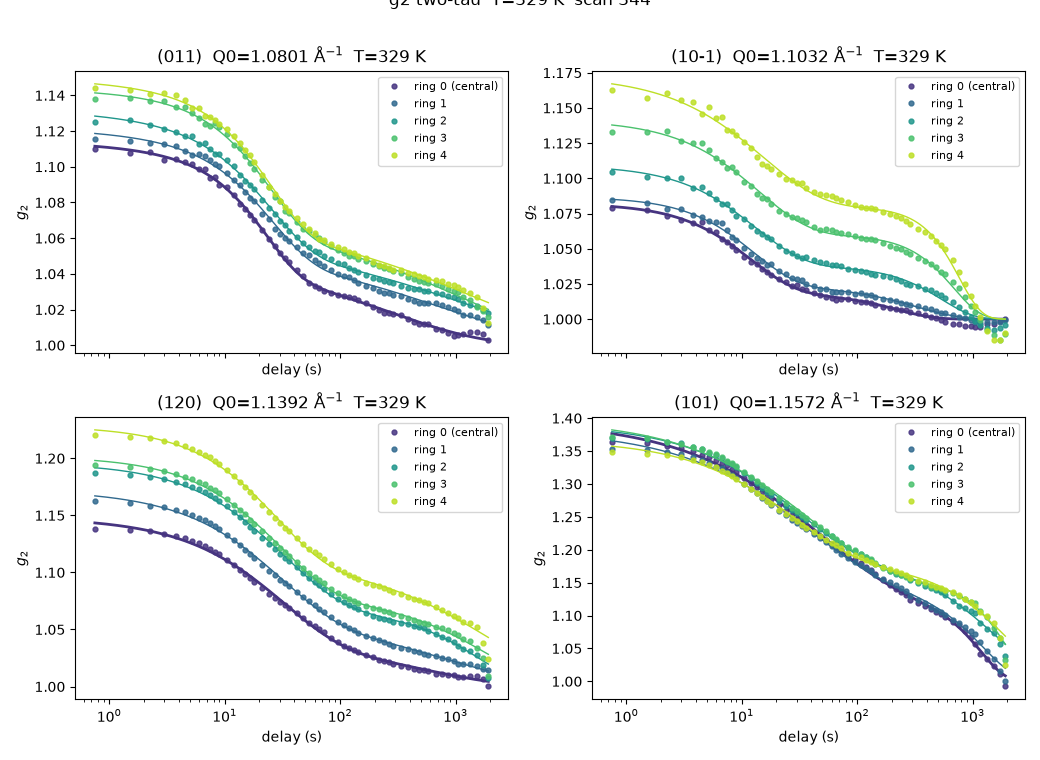

In [53]:
n = len(fits)
ncols = 2 if n > 1 else 1
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), sharex=True, squeeze=False)
for ax, fit in zip(axes.ravel(), sorted(fits, key=lambda f: f['Q0'])):
    plot_g2_fits(fit, ax=ax)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
fig.suptitle(f'g2 two-tau  T={Temperature} K  scan {Scan}', y=1.01)
fig.tight_layout()

# Fast $\tau$ and $\beta$ vs $Q_0$

Skip this for a single (111) file — one Q point is not a Q-dependence. Use the temperature compile below.

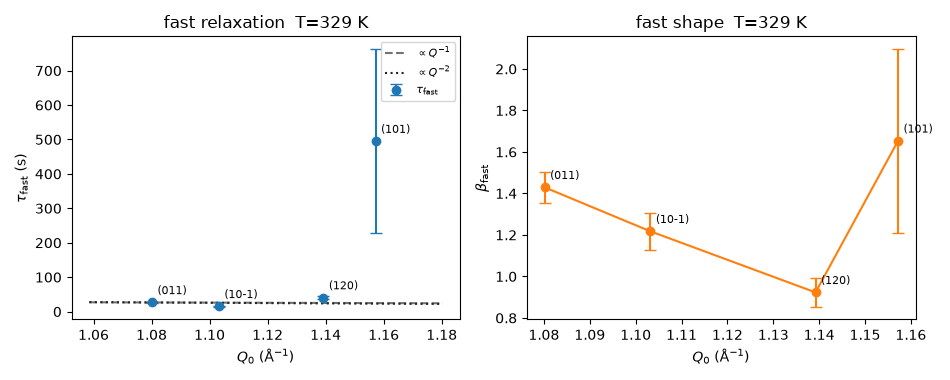

In [49]:
if len(fits) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
    plot_qdep(fits, axes=axes)
    fig.tight_layout()
else:
    f = fits[0]
    print(f"single peak ({f['reflection']})  Q0={f['Q0']:.4f}  "
          f"tau_fast={f['tau_fast']:.4g}±{f['tau_fast_err']:.3g}  "
          f"beta_fast={f['beta_fast']:.3g}±{f['beta_fast_err']:.3g}")

# Compile Q-dependence (four-peak temperatures)

Run this after 320, 329, 339, and 350 K each have a `results/qdep_T*K.h5`. Single-peak (111) files are left out of this figure.

four-peak files
  T=320 K  /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A343_NaBH_att000020_320K_001/results/qdep_T320K.h5
  T=329 K  /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A344_NaBH_att000020_329K_001/results/qdep_T329K.h5
  T=339 K  /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A349_NaBH_att000020_339K_001/results/qdep_T339K.h5
  T=350 K  /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A350_NaBH_att000020_350K_001/results/qdep_T350K.h5
compiled /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/qdep_compiled.h5


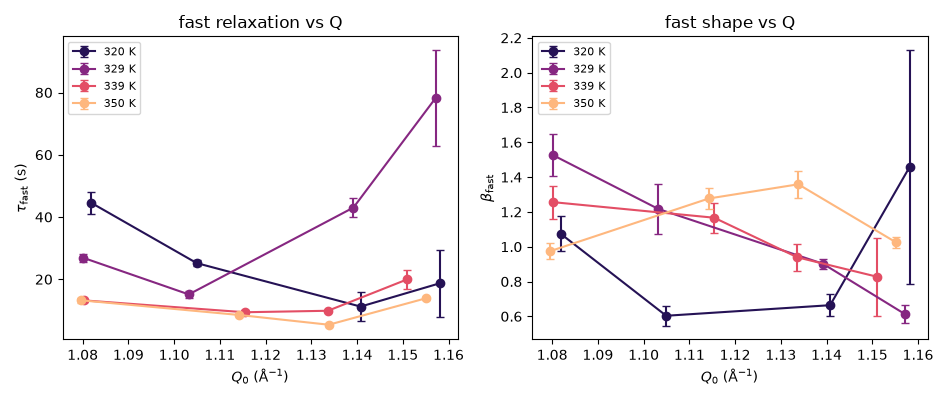

In [20]:
base = Path(config['Base']) if config.get('Base') else work_path.parent
qdep_files = discover_qdep_files(base)
rows = [load_temperature_qdep(p) for p in qdep_files]
multi = [r for r in rows if len(r['reflection']) > 1]
print('four-peak files')
for r in multi:
    print(f"  T={r['temperature']:g} K  {r['path']}")

if multi:
    compiled = compile_qdep([r['path'] for r in multi], base / 'qdep_compiled.h5')
    print('compiled', compiled)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))
    cmap = plt.cm.magma(np.linspace(0.15, 0.85, max(len(multi), 2)))
    for color, row in zip(cmap, multi):
        label = f"{row['temperature']:g} K"
        axes[0].errorbar(row['Q0'], row['tau_fast'], yerr=row['tau_fast_err'],
                         fmt='o-', capsize=3, color=color, label=label)
        axes[1].errorbar(row['Q0'], row['beta_fast'], yerr=row['beta_fast_err'],
                         fmt='o-', capsize=3, color=color, label=label)
    axes[0].set_xlabel(r'$Q_0$ (Å$^{-1}$)')
    axes[0].set_ylabel(r'$\tau_\mathrm{fast}$ (s)')
    axes[0].set_title('fast relaxation vs Q')
    axes[0].legend(fontsize=8)
    axes[1].set_xlabel(r'$Q_0$ (Å$^{-1}$)')
    axes[1].set_ylabel(r'$\beta_\mathrm{fast}$')
    axes[1].set_title('fast shape vs Q')
    axes[1].legend(fontsize=8)
    fig.tight_layout()
else:
    print('no four-peak qdep_T*K.h5 files yet')

# Single-peak (111) vs temperature

360–420 K each have one file, `(111)`. Same fit as above: set `reflections = SINGLE_PEAK` and step through `SINGLE_PEAK_SCANS`, or run the loop below after you have checked one overlay.

The compile is \(\tau(T)\) and \(\beta(T)\) at that one Q, not Q-dependence.

remaining (111) scans: ((360, 353), (370, 354), (380, 358), (399, 362), (420, 363))
(111) temperatures: [360. 370. 380. 399. 420.]


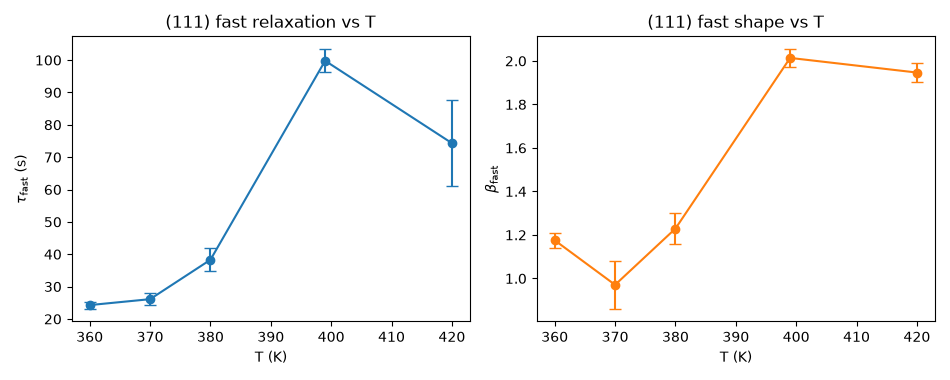

In [21]:
print('remaining (111) scans:', SINGLE_PEAK_SCANS)

# Optional batch after you have inspected one temperature:
# for Temperature, Scan in SINGLE_PEAK_SCANS:
#     work_path = resolve_work_path(Compound, Scan, Temperature, Attenuation, config=config)
#     fit_temperature(work_path / 'results', reflections=SINGLE_PEAK, trunc=trunc,
#                     write_back=write_back, save=save_qdep)

all_rows = [load_temperature_qdep(p) for p in discover_qdep_files(base)]
series = reflection_series(all_rows, '111')
print(f"(111) temperatures: {series['temperature']}")
if series['temperature'].size:
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
    plot_tdep(series, axes=axes)
    fig.tight_layout()
else:
    print('no (111) qdep files yet — fit those scans first')